# EDA y Data Storytelling — Películas de Letterboxd
**Dataset:** `movies_clean_ordered.csv` · 38,308 títulos · 7 columnas

**Guion del análisis:** contexto → variables (y sorpresas) → wrangling → 4 insights con gráfico → "so what".


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Paleta "cine" (verdes/turquesas sobre fondo oscuro)
BG, FG, GRID = "#04141A", "#E6F5F0", "#1E4650"
GREEN, TEAL, DEEP = "#3DDC97", "#1FA3B8", "#145B6B"
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110, "axes.titleweight": "bold",
    "figure.facecolor": BG, "axes.facecolor": BG, "savefig.facecolor": BG,
    "text.color": FG, "axes.labelcolor": FG, "axes.titlecolor": FG,
    "xtick.color": FG, "ytick.color": FG, "axes.edgecolor": GRID, "grid.color": GRID,
    "legend.facecolor": BG, "legend.edgecolor": GRID,
})

df_raw = pd.read_csv("movies_clean_ordered.csv")
df_raw.head()

,id,name,date,tagline,description,minute,rating
0,100001,Barbie,2023,She's everything. He's just Ken.,"Barbie and Ken are having the time of their lives in the colorful and seemingly perfect world of Barbie Land. However, when they get a chance to go to the real world, they soon discover the joys and perils of living among humans.",114,3.86
1,100002,Parasite,2019,Act like you own the place.,"All unemployed, Ki-taek's family takes peculiar interest in the wealthy and glamorous Parks for their livelihood until they get entangled in an unexpected incident.",133,4.56
2,100003,Everything Everywhere All at Once,2022,The universe is so much bigger than you realize.,"An aging Chinese immigrant is swept up in an insane adventure, where she alone can save what's important to her by connecting with the lives she could have led in other universes.",140,4.30
3,100004,Fight Club,1999,Mischief. Mayhem. Soap.,"A ticking-time-bomb insomniac and a slippery soap salesman channel primal male aggression into a shocking new form of therapy. Their concept catches on, with underground ""fight clubs"" forming in every town, until an eccentric gets in the way and ignites an out-of-control spiral toward oblivion.",139,4.27
4,100005,La La Land,2016,Here's to the fools who dream.,"Mia, an aspiring actress, serves lattes to movie stars in between auditions and Sebastian, a jazz musician, scrapes by playing cocktail party gigs in dingy bars, but as success mounts they are faced with decisions that begin to fray the fragile fabric of their love affair, and the dreams they worked so hard to maintain in each other threaten to rip them apart.",129,4.09


## 1. ¿Qué es este dataset?
Un catálogo de ~38 mil películas (con algunos títulos que en realidad son series, ver más abajo) con su año, duración, sinopsis y **rating promedio de la comunidad** (escala de 0.5 a 5 estrellas, estilo Letterboxd). El archivo se llama *ordered*: los `id` empiezan en 100001 con títulos muy populares (Barbie, Parasite, Everything Everywhere All at Once, Fight Club…), lo que sugiere que **`id` es un ranking de popularidad**, no un identificador arbitrario. Es una hipótesis que verificamos con los datos en el Insight 1.

## 2. ¿Qué significa cada columna? (tipo asignado vs. tipo real)

In [2]:
print(df_raw.shape)
df_raw.info()

(38308, 7)
<class 'pandas.DataFrame'>
RangeIndex: 38308 entries, 0 to 38307
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           38308 non-null  int64  
 1   name         38308 non-null  str    
 2   date         38308 non-null  int64  
 3   tagline      38308 non-null  str    
 4   description  38308 non-null  str    
 5   minute       38308 non-null  int64  
 6   rating       38308 non-null  float64
dtypes: float64(1), int64(3), str(3)
memory usage: 2.0 MB


In [3]:
tipos = pd.DataFrame({
    "columna": df_raw.columns,
    "dtype_pandas": df_raw.dtypes.astype(str).values,
    "tipo_real": [
        "Identificador / ranking ordinal (NO es una cantidad: sumarlo o promediarlo no tiene sentido)",
        "Texto (título). Se repite: hay remakes y homónimos",
        "Año de estreno (entero, NO fecha completa; funciona como variable temporal/ordinal)",
        "Texto libre (eslogan)",
        "Texto libre (sinopsis)",
        "Numérica continua: duración en minutos",
        "Numérica continua: rating promedio 0.5–5 (un promedio de muchos votos, por eso tiene decimales)",
    ],
})
tipos

,columna,dtype_pandas,tipo_real
0,id,int64,Identificador / ranking ordinal (NO es una cantidad: sumarlo o promediarlo no tiene sentido)
1,name,str,Texto (título). Se repite: hay remakes y homónimos
2,date,int64,"Año de estreno (entero, NO fecha completa; funciona como variable temporal/ordinal)"
3,tagline,str,Texto libre (eslogan)
4,description,str,Texto libre (sinopsis)
5,minute,int64,Numérica continua: duración en minutos
6,rating,float64,"Numérica continua: rating promedio 0.5–5 (un promedio de muchos votos, por eso tiene decimales)"


**Sorpresas al ver las columnas por primera vez:**
- `date` se llama *fecha* pero solo trae el **año** (y 2024 está incompleto).
- `id` parece ser un **ranking de popularidad**, no un ID neutral.
- `minute` llega hasta **2,250 min (37.5 horas)** y baja hasta **1 minuto**: aquí hay series de TV y cortometrajes mezclados con largometrajes.
- No hay nulos, pero eso no significa que los datos estén "limpios" (ver siguiente sección).

## 3. Wrangling: duplicados, faltantes y rangos

In [4]:
print("Nulos por columna:")
print(df_raw.isna().sum(), "\n")
print("Filas completamente duplicadas:", df_raw.duplicated().sum())
print("id duplicados:", df_raw["id"].duplicated().sum())
print("Títulos repetidos (name):", df_raw["name"].duplicated().sum())
print("Repetidos por (name + date):", df_raw.duplicated(["name", "date"]).sum())
print("Cadenas vacías / solo espacios:", (df_raw.select_dtypes("object").apply(lambda s: s.str.strip().eq("")).sum().sum()
      if len(df_raw.select_dtypes("object").columns) else 0))

Nulos por columna:
id             0
name           0
date           0
tagline        0
description    0
minute         0
rating         0
dtype: int64 

Filas completamente duplicadas: 0
id duplicados: 0
Títulos repetidos (name): 2628
Repetidos por (name + date): 47
Cadenas vacías / solo espacios: 0


In [5]:
# ¿Los repetidos por (name+date) son duplicados reales o homónimos del mismo año?
rep = df_raw[df_raw.duplicated(["name", "date"], keep=False)].sort_values(["name", "date"])
rep[["id", "name", "date", "minute", "rating"]].head(12)

,id,name,date,minute,rating
8434,108435,ATM,2012,91,2.16
20846,120847,ATM,2012,123,3.24
3953,103954,Alone,2020,98,3.01
16465,116466,Alone,2020,92,2.25
1199,101200,Anastasia,1997,94,3.79
36757,136758,Anastasia,1997,48,3.04
3215,103216,Beast,2022,93,2.53
11297,111298,Beast,2022,155,2.18
14929,114930,Beneath,2013,90,1.83
23315,123316,Beneath,2013,89,2.57


Los `name + date` repetidos tienen **distinta duración/rating y sinopsis distinta**, así que son homónimos del mismo año (no duplicados), y se conservan. Los remakes (ej. *13 Assassins* 1963 vs 2010) también se conservan a propósito: son películas distintas.

In [6]:
print(df_raw[["date", "minute", "rating"]].describe().round(2))
print("\nDuración <= 5 min:", (df_raw.minute <= 5).sum())
print("Duración < 40 min (cortometrajes):", (df_raw.minute < 40).sum())
print("Duración >= 240 min (posibles series):", (df_raw.minute >= 240).sum())
print("Duración >= 1000 min:", (df_raw.minute >= 1000).sum())
print("Películas de 2024:", (df_raw.date == 2024).sum(), "(año incompleto)")

           date    minute    rating
count  38308.00  38308.00  38308.00
mean    1997.09    105.32      3.15
std       24.54     81.10      0.47
min     1890.00      1.00      0.88
25%     1984.00     87.00      2.86
50%     2006.00     96.00      3.19
75%     2016.00    110.00      3.45
max     2024.00   2250.00      4.69

Duración <= 5 min: 229
Duración < 40 min (cortometrajes): 1347
Duración >= 240 min (posibles series): 676
Duración >= 1000 min: 104
Películas de 2024: 307 (año incompleto)


In [7]:
# Ver los extremos de duración para entender qué son
extremos = pd.concat([
    df_raw.nsmallest(4, "minute"), df_raw.nlargest(6, "minute")
])[["id", "name", "date", "minute", "rating"]]
extremos

,id,name,date,minute,rating
13043,113044,rain,2019,1,3.99
15474,115475,The Wait,2020,1,2.80
19612,119613,Playing Cards,1896,1,2.68
21367,121368,asdfmovie3,2010,1,3.25
11950,111951,The Untamed,2019,2250,4.23
11984,111985,Taxi Driver,2021,2064,4.03
5969,105970,Reply 1988,2015,1900,4.45
10146,110147,Mr. Sunshine,2018,1800,4.22
27901,127902,Flowers in the Attic: The Origin,2022,1644,3.38
6508,106509,Vincenzo,2021,1620,4.07


**Decisiones de limpieza** (documentadas, no se borra nada sin razón):
1. **No se eliminan duplicados**: no hay filas ni `id` duplicados; los títulos repetidos son remakes/homónimos legítimos.
2. **No hay faltantes**, así que no hay imputación.
3. Se crean *banderas* de tipo de título según duración: `corto` (<40 min), `largometraje` (40–239) y `posible_serie` (≥240 min). Los extremos son reales (series / cortos catalogados como película), así que se **etiquetan** en lugar de borrarlos.
4. Se crea `rank = id - 100000` para tratar `id` como lo que parece ser: posición en el ranking.
5. Se excluye 2024 de las comparaciones por año/década (año incompleto).

In [8]:
df = df_raw.copy()
df["rank"] = df["id"] - 100000
df["decada"] = (df["date"] // 10) * 10
df["tipo"] = pd.cut(df["minute"], bins=[0, 39, 239, np.inf],
                    labels=["corto (<40 min)", "largometraje (40-239)", "posible serie (>=240)"])
df["tipo"].value_counts()

tipo
largometraje (40-239)    36285
corto (<40 min)           1347
posible serie (>=240)      676
Name: count, dtype: int64

### Distribución de la duración (por qué hay que separar tipos)

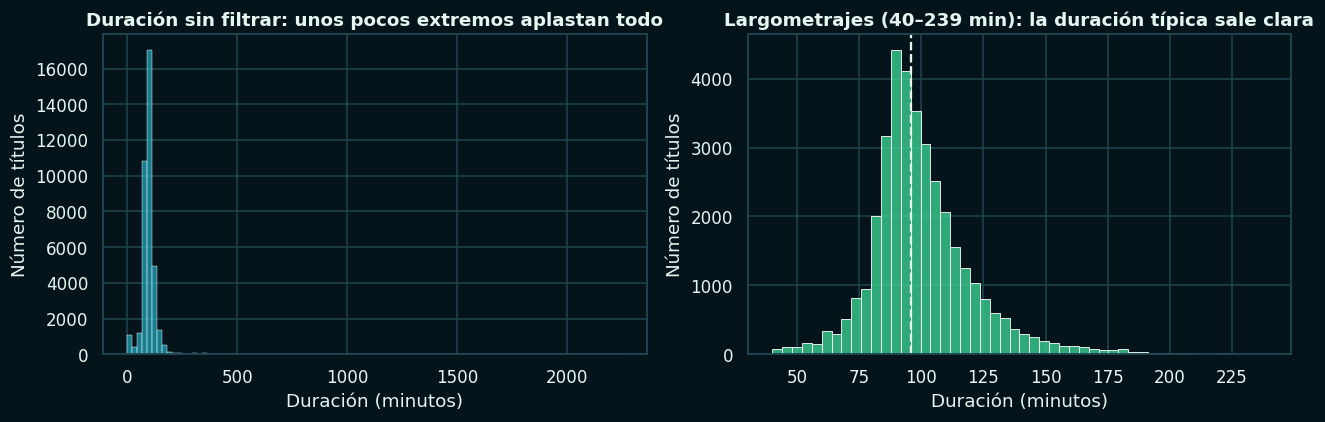

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["minute"], bins=100, ax=ax[0], color=TEAL)
ax[0].set(title="Duración sin filtrar: unos pocos extremos aplastan todo",
          xlabel="Duración (minutos)", ylabel="Número de títulos")
sns.histplot(df[df["minute"].between(40, 239)]["minute"], bins=50, ax=ax[1], color=GREEN)
ax[1].set(title="Largometrajes (40–239 min): la duración típica sale clara",
          xlabel="Duración (minutos)", ylabel="Número de títulos")
ax[1].axvline(df[df["minute"].between(40, 239)]["minute"].median(), color=FG, ls="--")
plt.tight_layout(); plt.show()

## 4. Insights

### Insight 1 — Lo popular (según `id`) también se califica mejor
Verificamos la hipótesis de que `id` es un ranking de popularidad.

               mean  median  count
bloque_rank                       
Top 1–1,000    3.66    3.73   1000
1,001–5,000    3.29    3.36   4000
5,001–10,000   3.20    3.27   5000
10,001–20,000  3.08    3.15  10000
20,001+        3.11    3.16  18308

Correlación de Spearman rank vs rating: -0.16


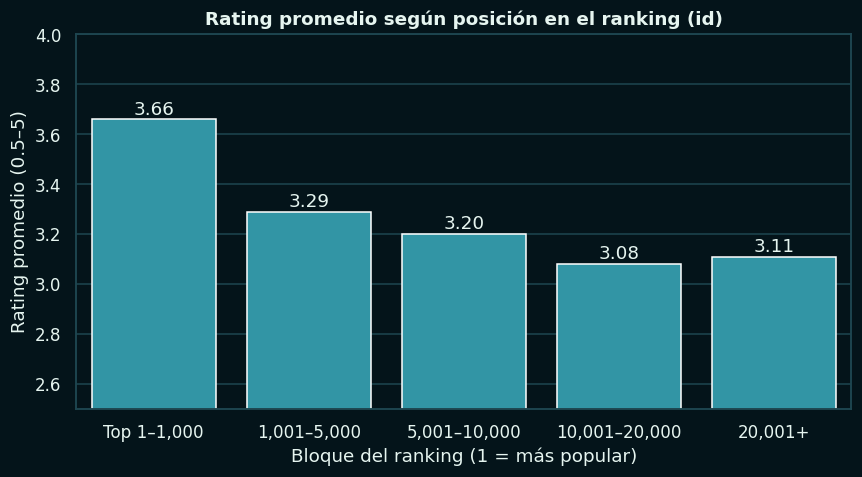

In [10]:
df["bloque_rank"] = pd.cut(df["rank"], bins=[0, 1000, 5000, 10000, 20000, 40000],
    labels=["Top 1–1,000", "1,001–5,000", "5,001–10,000", "10,001–20,000", "20,001+"])
r1 = df.groupby("bloque_rank", observed=True)["rating"].agg(["mean", "median", "count"]).round(2)
print(r1)
rho = df[["rank", "rating"]].corr(method="spearman").iloc[0, 1]
print(f"\nCorrelación de Spearman rank vs rating: {rho:.2f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=r1.index, y=r1["mean"], ax=ax, color=TEAL)
for i, v in enumerate(r1["mean"]):
    ax.text(i, v + 0.02, f"{v:.2f}", ha="center")
ax.set(title="Rating promedio según posición en el ranking (id)",
       xlabel="Bloque del ranking (1 = más popular)", ylabel="Rating promedio (0.5–5)", ylim=(2.5, 4))
plt.tight_layout(); plt.show()

**So what:** el top 1,000 promedia 3.66 vs 3.13 del resto: **+0.53 estrellas**. Lo que más gente ve/registra también se califica mejor. Ojo: la relación es moderada (ρ ≈ −0.16), y la caída se estabiliza después de las primeras ~10 mil posiciones, así que el efecto es más fuerte en la "élite" que a lo largo de todo el catálogo. Para una plataforma, el rating de una película poco vista es un dato más ruidoso y menos informativo que el de una popular.

### Insight 2 — La duración "muerta" es de 80–100 min; a más duración, mejor rating
No es una relación lineal: las películas de 80–100 min (las más comunes) son las peor calificadas.

            mean  count
bloque_min             
≤40         3.39   1371
41–60       3.31    708
61–80       3.10   3347
81–100      3.02  17720
101–120     3.20   9792
121–150     3.33   3649
151–180     3.41    807
181–240     3.60    269
>240        3.69    645


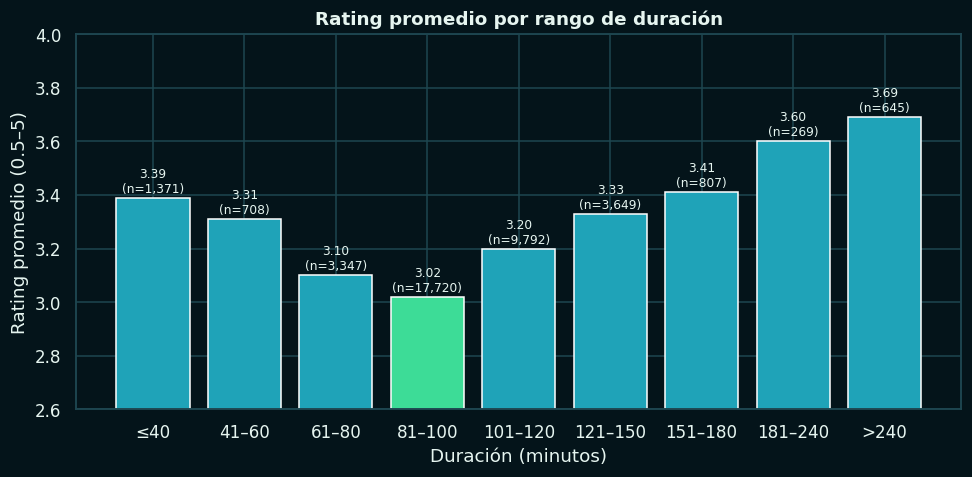

In [11]:
lf = df[df["tipo"] == "largometraje (40-239)"].copy()
df["bloque_min"] = pd.cut(df["minute"], bins=[0, 40, 60, 80, 100, 120, 150, 180, 240, 5000],
    labels=["≤40", "41–60", "61–80", "81–100", "101–120", "121–150", "151–180", "181–240", ">240"])
r2 = df.groupby("bloque_min", observed=True)["rating"].agg(["mean", "count"]).round(2)
print(r2)

fig, ax = plt.subplots(figsize=(9, 4.5))
colores = [GREEN if l == "81–100" else TEAL for l in r2.index]
ax.bar(r2.index.astype(str), r2["mean"], color=colores)
for i, (v, n) in enumerate(zip(r2["mean"], r2["count"])):
    ax.text(i, v + 0.02, f"{v:.2f}\n(n={n:,})", ha="center", fontsize=8)
ax.set(title="Rating promedio por rango de duración",
       xlabel="Duración (minutos)", ylabel="Rating promedio (0.5–5)", ylim=(2.6, 4.0))
plt.tight_layout(); plt.show()

**So what:** el rango de **81–100 min concentra 46% del catálogo (17,720 títulos) y tiene el peor rating (3.02)**. Es la duración "de cajón" del cine comercial de bajo presupuesto/género. En el otro extremo, lo que dura más de 3 horas promedia ~3.6–3.7. Parte de esto es *sesgo de selección*: una película larga solo se hace (y se ve completa) si hay ambición/respaldo detrás, y las duraciones extremas incluyen series. Para quien produce: alargar no mejora la película por sí solo, pero las cintas ambiciosas suelen ser largas.

### Insight 3 — El cine viejo "parece" mejor calificado: sesgo de supervivencia

        rating      n
decada               
1920      3.46    226
1930      3.33   1023
1940      3.35   1228
1950      3.33   1561
1960      3.31   1810
1970      3.25   2568
1980      3.15   3242
1990      3.15   3900
2000      3.11   6079
2010      3.06  11034
2020      3.10   5250


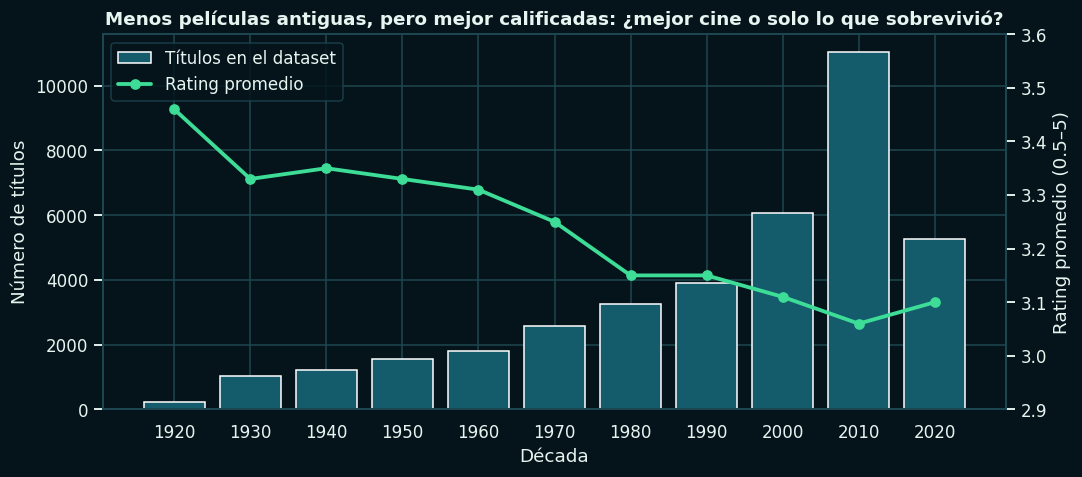

In [12]:
d = df[(df["date"] < 2024) & (df["date"] >= 1920)]
r3 = d.groupby("decada").agg(rating=("rating", "mean"), n=("id", "count")).round(2)
print(r3)

fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax1.bar(r3.index.astype(str), r3["n"], color=DEEP, label="Títulos en el dataset")
ax1.set(xlabel="Década", ylabel="Número de títulos")
ax2 = ax1.twinx()
ax2.plot(r3.index.astype(str), r3["rating"], color=GREEN, marker="o", lw=2.5, label="Rating promedio")
ax2.set(ylabel="Rating promedio (0.5–5)", ylim=(2.9, 3.6)); ax2.grid(False)
ax1.set_title("Menos películas antiguas, pero mejor calificadas: ¿mejor cine o solo lo que sobrevivió?")
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left")
plt.tight_layout(); plt.show()

**So what:** los años 20 promedian ~3.46 y los 2010, ~3.06. Pero hay 226 películas de los 20 y 11,034 de los 2010. Lo más probable es que **solo se conservan, digitalizan y se ven las películas antiguas que ya son consideradas buenas** (sesgo de supervivencia), no que el cine de antes fuera mejor. Es una advertencia para cualquiera que compare épocas con este tipo de datos.

### Insight 4 — Las "películas" de más de 4 horas son, en realidad, series y están explotando

decada
1970     15
1980     19
1990     20
2000     41
2010    176
2020    365
dtype: int64

Rating promedio >=240 min: 3.68 | largometrajes: 3.13


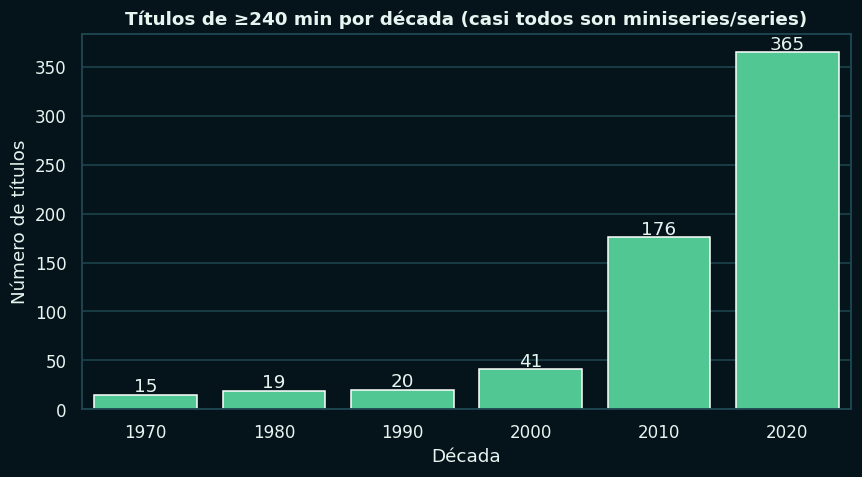

,rank,name,date,minute,rating
423,424,Squid Game,2021,495,3.73
480,481,WandaVision,2021,350,3.75
588,589,Zack Snyder's Justice League,2021,242,3.41
601,602,Loki,2021,615,3.78
606,607,Normal People,2020,342,4.42
636,637,Chernobyl,2019,327,4.57
858,859,Moon Knight,2022,282,3.57
872,873,BEEF,2023,351,4.24


In [13]:
largas = df[(df["minute"] >= 240) & (df["date"] < 2024)]
r4 = largas.groupby("decada").size()
r4 = r4[r4.index >= 1970]
print(r4)
print("\nRating promedio >=240 min:", round(df[df.minute >= 240].rating.mean(), 2),
      "| largometrajes:", round(df[df.tipo == 'largometraje (40-239)'].rating.mean(), 2))

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=r4.index.astype(str), y=r4.values, ax=ax, color=GREEN)
for i, v in enumerate(r4.values):
    ax.text(i, v + 3, str(v), ha="center")
ax.set(title="Títulos de ≥240 min por década (casi todos son miniseries/series)",
       xlabel="Década", ylabel="Número de títulos")
plt.tight_layout(); plt.show()

df[df["minute"] >= 240].sort_values("rank").head(8)[["rank", "name", "date", "minute", "rating"]]

**So what:** en el top de estos títulos aparecen *Squid Game*, *Chernobyl*, *Loki*, *WandaVision*: **series de streaming catalogadas como película**. Pasaron de 20 títulos en los 90 a **176 en los 2010 y 365 en 2020–2023** (la década aún no termina). Además promedian 3.68 vs 3.13 de los largometrajes. Sirve como alerta de calidad de datos: cualquier análisis de "duración de películas" sin filtrar está contaminado por series. Y también cuenta una historia cultural: el auge del streaming se ve en los datos.

## 5. Conclusión
- El dataset no es solo "películas": tiene **series, cortos y un `id` que en realidad es un ranking**.
- Popularidad, duración y época **no se relacionan con el rating de forma simple**: hay sesgos de selección/supervivencia detrás.
- Lo más valioso del análisis fue *entender qué representa cada columna*, no solo graficarla.